In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "D:/Programming/Git/ClustPy")

In [3]:
from clustpy.metrics.tests.test_metrics_utils import (
    test_assign_all_noise_points_to_one_cluster,
    test_assign_each_noise_point_to_singleton_cluster,
    test_remove_noise_point,
    test_assign_all_noise_points_to_nearest_cluster,
    test_handle_noise,
)

test_assign_all_noise_points_to_one_cluster()
test_assign_each_noise_point_to_singleton_cluster()
test_remove_noise_point()
test_assign_all_noise_points_to_nearest_cluster()
test_handle_noise()

In [4]:
from clustpy.metrics import cvnn_score 
from clustpy.data import load_iris

dataset = load_iris()
X, l = dataset.data, dataset.target

cvnn_score(X, l)

[WARNING] Could not import nltk in clustpy.data.real_world_data to use the SnowballStemmer. Please install nltk by 'pip install nltk' if necessary
[WARNING] Could not import cv2 in clustpy.data.real_video_data. Please install cv2 by 'pip install opencv-python' if necessary


np.float64(2.9589583534483754)

In [6]:
from clustpy.metrics.internal_clustering_metrics import cvdd_score
from clustpy.metrics.internal_clustering_metrics.viasckde import viasckde_score, viasckde_score_

viasckde_score(X, l), viasckde_score_(X, l)

(np.float64(0.1344269283408734), np.float64(0.1344269283408734))

In [ ]:
# internal packages
import os
from collections import Counter
# external packages
import torch
import torchvision
import numpy as np
import sklearn
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_rand_score
from clustpy.metrics import unsupervised_clustering_accuracy
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

%matplotlib inline
import pandas as pd
import clustpy
from clustpy.deep import encode_batchwise, get_dataloader
import joblib
import logging

# specify base paths
data_path = "/"
base_path = "models" 

In [ ]:
# Some helper functions
def denormalize_fn(tensor: torch.Tensor, mean, std, shape=None, **kwargs) -> torch.Tensor:
    """
    This applies an inverse z-transformation and reshaping to visualize the images properly.
    """
    if shape is None:
        shape = tensor.shape
    if len(shape) == 3:
        n_channels, width, height = shape
    else:
        _, n_channels, width, height = shape

    pt_std = torch.as_tensor(std, dtype=torch.float32, device=tensor.device)
    pt_mean = torch.as_tensor(mean, dtype=torch.float32, device=tensor.device)
    unnormalize_fn = torchvision.transforms.Normalize((-pt_mean / pt_std).tolist(), (1.0 / pt_std).tolist())
    tensor_view = tensor.view(-1, n_channels, width, height)
    # tensor_view = unnormalize_fn(tensor_view)
    tensor_view = torch.stack([unnormalize_fn(tensor_view[i]) for i in range(tensor_view.shape[0])])

    return (tensor_view * 255).int().detach()


def plot_images(images: torch.Tensor, pad: int = 1, nrow=8):
    """Aligns multiple images on an N by nrow grid"""

    def imshow(img):
        plt.figure(figsize=(10, 20))
        npimg = img.numpy()
        npimg = np.array(npimg)
        plt.axis("off")
        plt.imshow(np.transpose(npimg, (1, 2, 0)), vmin=0, vmax=1)

    # code to avoid "Clipping ..." message, see https://stackoverflow.com/questions/54848310/disable-matplotlib-warning-when-using-pyplot-imshow
    logger = logging.getLogger()
    old_level = logger.level
    logger.setLevel(100)

    imshow(torchvision.utils.make_grid(images, pad_value=255, normalize=False, padding=pad, nrow=nrow))
    logger.setLevel(old_level)

    plt.show()


def detect_device():
    """Automatically detects if you have a cuda enabled GPU"""
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else:
        device = torch.device("cpu")
    return device


def get_label_subset(data, labels, label_subset):
    """Returns subset of selected labels"""
    labels_new = []
    data_new = []
    for label_i in label_subset:
        mask_i = labels == label_i
        labels_new.append(labels[mask_i].copy())
        data_new.append(data[mask_i].copy())
    data_new = np.concatenate(data_new)
    labels_new = np.concatenate(labels_new)
    return data_new, labels_new

In [ ]:
from clustpy.data import load_gtsrb

# specify which classes to use
label_subset = [4, 13, 35, 38]

# load signnames for interpretation
df = pd.read_csv("signnames.csv")
signnames = df.to_dict()["SignName"]
label_names = [f"{i}-{signnames[i]}" for i in label_subset]

# load data set
data, labels = load_gtsrb(return_X_y=True)
# Select subset of labels from data
data, labels = get_label_subset(data, labels, label_subset)
# convert data from numpy array to torch tensor
data = torch.from_numpy(data)
# print(data.shape)

print("Plot data before preprocessing")
# rnd_indices = np.random.randint(0, data.shape[0], 16).tolist()
# fix them for now to have same images in every output
rnd_indices = [2964, 191, 6759, 4936, 65, 2866, 4061, 2547, 1077, 5532, 5790, 1252, 2021, 4509, 2108, 5133]

data = torch.reshape(data, (data.shape[0], 32, 32, 3))
data = torch.permute(data, (0, 3, 1, 2))
plot_images(data[rnd_indices].int())

# apply histogram equalization
data = torchvision.transforms.functional.equalize(data.to(torch.uint8))

print("Plot data after preprocessing with Histogram Equalization")
plot_images(data[rnd_indices])

# convert data to torch.tensor float
data = data.float()
# scale data from 0-255 to 0 - 1
data /= 255.0


# calculate mean and standard deviation for the 3 RGB channels
mean = data.mean([0, 2, 3])
std = data.std([0, 2, 3])
# normalize channels
data -= mean.reshape(1, 3, 1, 1)
data /= std.reshape(1, 3, 1, 1)
# specify denormalization function for plotting
denormalize = lambda x: denormalize_fn(x, mean=mean, std=std, shape=(3, 32, 32))
# calculate new statistics for reference
_new_mean = data.mean([0, 2, 3])
_new_std = data.std([0, 2, 3])

# flatten data
data = data.reshape(-1, data.shape[1] * data.shape[2] * data.shape[3])

print("#" * 40)
print("Data Set Statistics")
print("#" * 40)
print(f"Number of instances: {data.shape[0]}")
print(f"Number of dimensions: {data.shape[1]}")
print(
    f"Mean before norm. [{mean[0]:.3f}, {mean[1]:.3f}, {mean[2]:.3f}] and after [{_new_mean[0]:.2f}, {_new_mean[1]:.2f}, {_new_mean[2]:.2f}]"
)
print(
    f"Std before norm.  [{std[0]:.3f}, {std[1]:.3f}, {std[2]:.3f}] and after [{_new_std[0]:.2f}, {_new_std[1]:.2f}, {_new_std[2]:.2f}]"
)
counter = Counter(labels.tolist())
print()
n_clusters = len(counter)
print("Number of clusters: ", n_clusters)
for label_i in label_subset:
    print(f"Size {label_i}-{signnames[label_i]}: {counter[label_i]}")
print("#" * 40)


[WARNING] Could not import nltk in clustpy.data.real_world_data to use the SnowballStemmer. Please install nltk by 'pip install nltk' if necessary
[WARNING] Could not import cv2 in clustpy.data.real_video_data. Please install cv2 by 'pip install opencv-python' if necessary


KeyboardInterrupt: 

ModuleNotFoundError: No module named 'clustpy.metrics.test_metrics_utils'

In [ ]:
from clustpy.deep import SHADE
from sklearn.metrics import adjusted_rand_score as ari

shade = SHADE(clustering_epochs=150)
l_ = shade.fit_predict(data)
emb = shade.encode(data)
ari(labels, l_)

Build DCTree of the complete dataset
Neural network is not fitted yet, will be pretrained.


AE training: 0it [00:00, ?it/s]

Start training with clustering loss.
Compute dc_distance matrix.


0.03356678033046556

PCA of original data and ground truth labels:


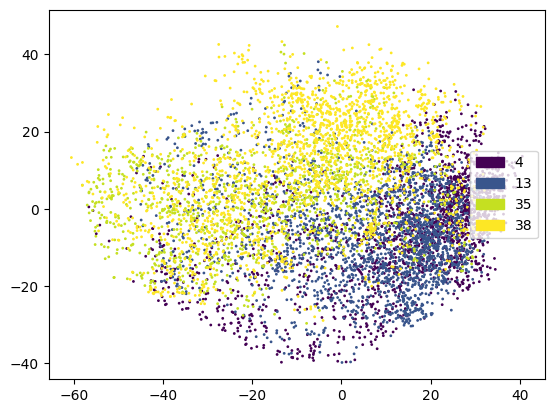

In [ ]:
from clustpy.utils import plot_with_transformation

print("PCA of original data and ground truth labels:")
plot_with_transformation(data, labels, scattersize=1, show_plot=False)

PCA of embedding and ground truth labels:


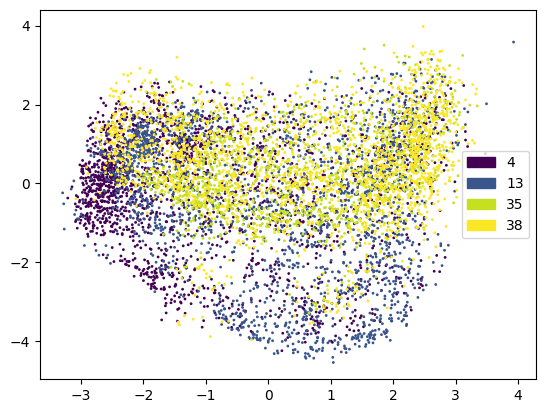

In [ ]:
print("PCA of embedding and ground truth labels:")
plot_with_transformation(emb, labels, scattersize=1, show_plot=False)

PCA of original data and labels of SHADE:


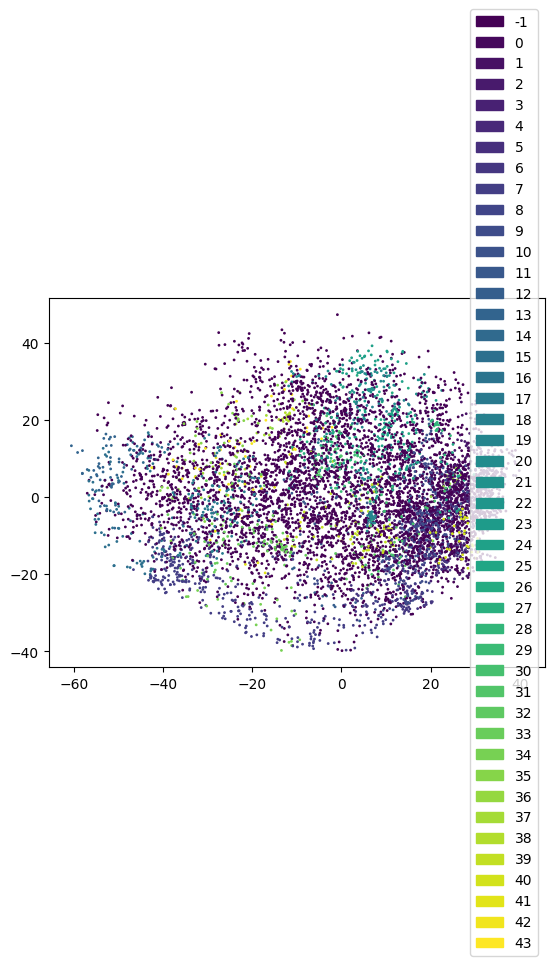

In [ ]:
print("PCA of original data and labels of SHADE:")
plot_with_transformation(data, l_, scattersize=1, show_plot=False)

PCA of embedding and labels of SHADE:


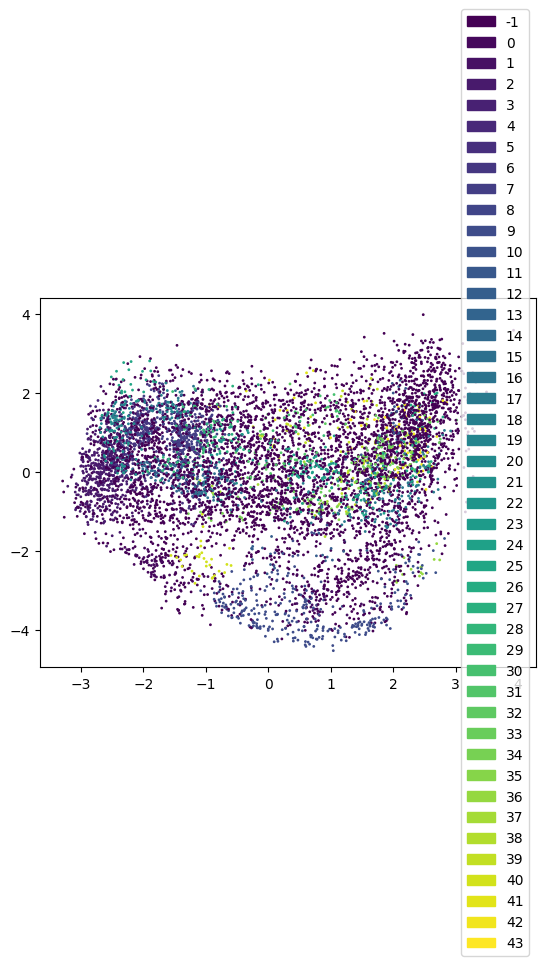

In [ ]:
print("PCA of embedding and labels of SHADE:")
plot_with_transformation(emb, l_, scattersize=1, show_plot=False)

### With SHIP-framework

In [ ]:
from SHiP import SHiP

# On original data:
ship = SHiP(data.numpy())
ship_labels = ship.fit_predict()
ari(labels, ship_labels)

0.18324570103374505

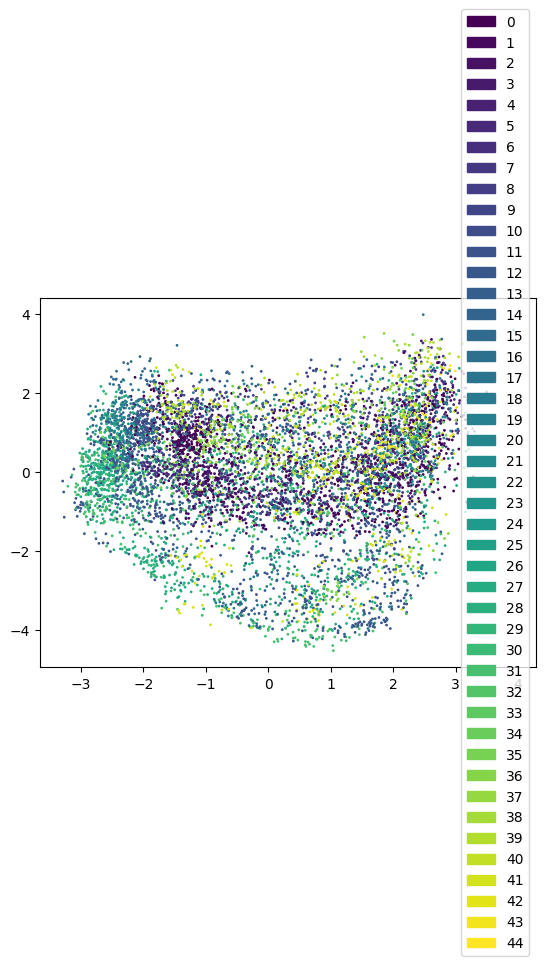

In [ ]:
plot_with_transformation(emb, ship_labels, scattersize=1, show_plot=False)

In [ ]:
ship.k = 4
ship_labels_k = ship.fit_predict(partitioningMethod="Threshold")
ari(labels, ship_labels_k)

0.13965534933424814

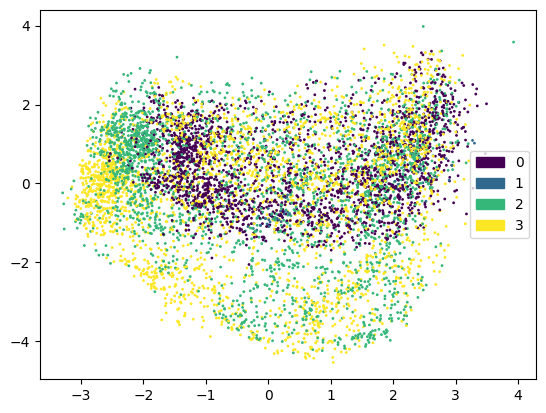

In [ ]:
plot_with_transformation(emb, ship_labels_k, scattersize=1, show_plot=False)

In [ ]:
# On SHADE embedding:
ship = SHiP(emb)
shade_ship_labels = ship.fit_predict()
ari(labels, ship_labels)

0.2556646922449778

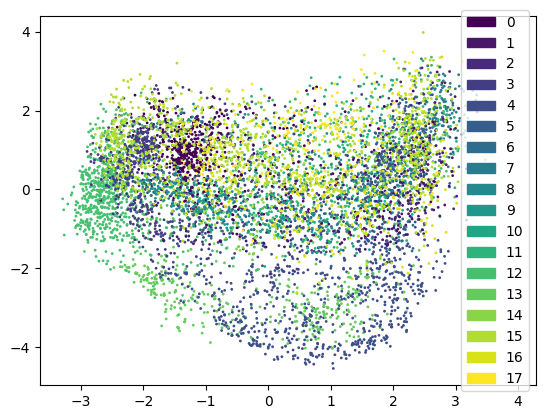

In [ ]:
plot_with_transformation(emb, shade_ship_labels, scattersize=1, show_plot=False)

In [ ]:
ship.k = 4
shade_ship_labels_k = ship.fit_predict(partitioningMethod="Threshold")
ari(labels, shade_ship_labels_k)

0.2749160461915894

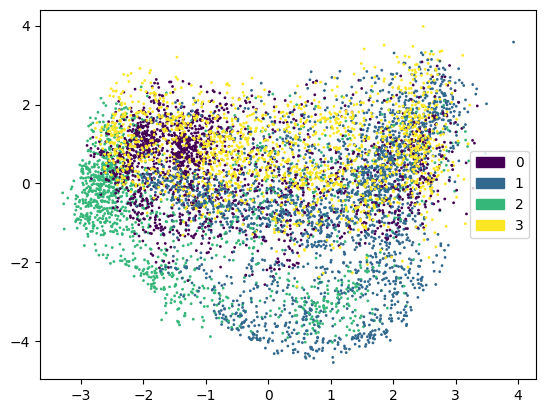

In [ ]:
plot_with_transformation(emb, shade_ship_labels_k, scattersize=1, show_plot=False)